# 5 — Modelos de Deep Learning

**Entrada:** `dataset_modelado.csv`, `harmonie_crudo.csv`, y opcionalmente
`ml_mejor_modelo.json` y `baselines_metricas.csv` para la comparación
**Salida:** `dl_predicciones.parquet`, `dl_mejor_modelo.json`

LSTM, GRU y un Transformer pequeño, cubriendo la parte de Deep Learning del objetivo 2 de la memoria
(Sección 1.3), en dos etapas:

| Etapa | Qué varía | Qué se fija | Objetivo |
|---|---|---|---|
| **1. Arquitectura** | LSTM / GRU / Transformer | Configuración modesta e idéntica, los 12 horizontes | Ver si alguna destaca sin afinar |
| **2. Afinado** | Ventana + arquitectura + regularización | Las tres arquitecturas, por separado | Mejor versión de cada una |
| **3. Comparación final** | Arquitectura | Configuración afinada + 3 semillas | Elegir la ganadora y medir el efecto de la semilla |

La ventana entra como un hiperparámetro más de la búsqueda, no se fija de antemano.

## Arquitectura de entrada

Cada modelo combina dos vías:

* **Secuencial**: la ventana de `W` lags de `obs_vel`, que termina en `t-H` (nunca en `t-1`).
  Si terminara en `t-1`, la red vería información no disponible al predecir.
* **Estática**: las mismas variables del conjunto B — `H_vel`, `H_dir_sin/cos`, `H_lead`,
  las cíclicas — más las de tendencia (`lag_media`, `lag_std`, `lag_tend`), concatenadas
  con la salida secuencial antes de la capa final.

Es la misma información que usó XGBoost, en otro formato: así la comparación aísla el
efecto de la arquitectura, no el de los datos disponibles.

## Por qué no cabe esperar una mejora grande

El SHAP del notebook 4 mostró que `H_vel` y `H_dir_sin` concentran casi toda la señal, y que
los lags aportan de forma marginal y decreciente. Esa es la firma de un problema con
**dependencias temporales cortas y relación mayormente aditiva** — justo donde el DL tiene
menos ventaja estructural sobre los árboles. Si el DL iguala a XGBoost sin superarlo, es en
sí mismo un resultado: confirma que la estructura del problema no premia la complejidad
añadida.

> **Nota sobre el dispositivo.** Medido en este equipo, la CPU resulta ~1.8x más rápida que
> MPS para estas redes: con ventanas cortas y lotes pequeños, el coste de transferir a la GPU
> domina sobre el cálculo. Por eso `DEVICE` se fija a CPU por defecto y se paralelizan los
> horizontes entre procesos, que rinde mucho más. Cambiar `PREFERIR_GPU = True` para forzar
> MPS/CUDA si se ejecuta en otra máquina con secuencias mayores.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import time, json, math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, StandardScaler as SKScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RUTA       = Path('.')
LATENCIA   = 4
OBJ        = 'obs_vel'
H_REF      = 12                 # horizonte de referencia para las etapas 1 y 2
HORIZONTES = list(range(1, 13))
VENTANAS   = [6, 12, 24]       # en la etapa 2 es un hiperparámetro más
SEMILLA    = 42
BATCH      = 64
EPOCHS_MAX = 100
PACIENCIA  = 15
TRIALS     = 25
N_SEMILLAS_ENSEMBLE = 3

# --- Dispositivo y paralelismo -------------------------------------------------
# Medido en este equipo (M5, ventana 12, batch 64): CPU 0.100 s/epoch frente a
# MPS 0.186 s/epoch. Con secuencias cortas el coste de mover datos a la GPU domina
# sobre el cálculo, así que MPS sale perdiendo. Como cada entrenamiento necesita
# pocos hilos, el paralelismo rinde mucho más repartiendo HORIZONTES entre procesos:
# medido 2x de aceleración, con resultados idénticos.
PREFERIR_GPU     = False   # True para forzar CUDA/MPS en otra máquina
N_HILOS_TORCH    = 2       # hilos por entrenamiento
N_JOBS_HORIZONTE = 3       # horizontes simultáneos (3 x 2 = 6 hilos)

if PREFERIR_GPU and torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif PREFERIR_GPU and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

torch.manual_seed(SEMILLA)
torch.set_num_threads(N_HILOS_TORCH)
plt.rcParams['figure.figsize'] = (11, 4)

base  = pd.read_csv(RUTA/'dataset_modelado.csv', index_col='ts', parse_dates=['ts'])
crudo = pd.read_csv(RUTA/'harmonie_crudo.csv', parse_dates=['valida', 'pasada'])
crudo['V']   = np.hypot(crudo.WSPE, crudo.WSPN)
crudo['Dir'] = (np.degrees(np.arctan2(-crudo.WSPE, -crudo.WSPN)) + 360) % 360

print(f'{len(base)} horas, {base.tramo.nunique()} tramos | torch {torch.__version__} '
      f'| dispositivo: {DEVICE}')

23719 horas, 13 tramos | torch 2.12.0 | dispositivo: cpu


---
## 1. Secuencias, escalado y arquitecturas

Las secuencias se recorren **por tramo**, para que ninguna ventana cruce un hueco de días.
Los escaladores se ajustan **solo con entrenamiento**: hacerlo con todo el dataset sería una
fuga, porque el modelo vería indirectamente la media y desviación del test.

Las tres arquitecturas comparten la misma cabeza (concatenación con las estáticas + MLP
pequeño) y solo difieren en cómo procesan la secuencia. LSTM y GRU admiten además
bidireccionalidad, que la búsqueda de la etapa 2 puede activar.

In [2]:
CICLICAS = ['hora_sin', 'hora_cos', 'dia_sin', 'dia_cos']
HARM_VEL = ['H_vel', 'H_dir_sin', 'H_dir_cos', 'H_lead']
ESTATICAS_BASE = CICLICAS + HARM_VEL
NOMBRES_TREND  = ['lag_media', 'lag_std', 'lag_tend']
ESTATICAS = ESTATICAS_BASE + NOMBRES_TREND

def harmonie_para(H):
    apto = crudo[crudo.lead >= H + LATENCIA].sort_values(['valida', 'pasada'])
    oper = apto.groupby('valida').last()
    h = pd.DataFrame({'H_vel': oper['V'], 'H_lead': oper['lead'],
                      'H_dir_sin': np.sin(np.radians(oper['Dir'])),
                      'H_dir_cos': np.cos(np.radians(oper['Dir']))})
    h.index.name = 'ts'
    return h

def preparar_base(H):
    d = (base.drop(columns=[c for c in base.columns if c.startswith('H_')], errors='ignore')
             .join(harmonie_para(H), how='inner'))
    return d.dropna(subset=[OBJ] + ESTATICAS_BASE)

def split_temporal_idx(d, frac_tr=.6, frac_va=.2):
    n = len(d)
    i1, i2 = int(n*frac_tr), int(n*(frac_tr+frac_va))
    return d.index[:i1], d.index[i1:i2], d.index[i2:]

def construir_secuencias(d, idxs, W, H):
    """Ventana de W lags que TERMINA en t-H (nunca en t-1), más estáticas y tendencia."""
    Xs, Xe, ys, idx_out = [], [], [], []
    idxs_set = set(idxs)
    for _, g in d.groupby('tramo'):
        g = g.sort_index()
        vel, est_base = g[OBJ].values, g[ESTATICAS_BASE].values
        for i in range(len(g)):
            if g.index[i] not in idxs_set:
                continue
            ini = i - H - W + 1
            if ini < 0:
                continue
            ventana = vel[ini:i - H + 1]
            if len(ventana) != W:
                continue
            Xs.append(ventana)
            Xe.append(list(est_base[i]) +
                      [ventana.mean(), ventana.std(), ventana[0] - ventana[-1]])
            ys.append(vel[i])
            idx_out.append(g.index[i])
    return (np.array(Xs), np.array(Xe, dtype=float), np.array(ys),
            pd.DatetimeIndex(idx_out))

def ajustar_escaladores(Xs, Xe, y):
    return (StandardScaler().fit(Xs.reshape(-1, 1)),
            StandardScaler().fit(Xe),
            StandardScaler().fit(y.reshape(-1, 1)))

def escalar(Xs, Xe, y, sc_seq, sc_est, sc_y, device=None):
    dev = device or DEVICE
    Xs2 = sc_seq.transform(Xs.reshape(-1, 1)).reshape(Xs.shape)
    return (torch.tensor(Xs2, dtype=torch.float32).unsqueeze(-1).to(dev),
            torch.tensor(sc_est.transform(Xe), dtype=torch.float32).to(dev),
            torch.tensor(sc_y.transform(y.reshape(-1, 1)), dtype=torch.float32).squeeze(-1).to(dev))

class LSTMReg(nn.Module):
    def __init__(self, n_est, hidden=32, capas=1, dropout=0.0, bidir=False):
        super().__init__()
        self.rnn = nn.LSTM(1, hidden, num_layers=capas, batch_first=True,
                           dropout=dropout if capas > 1 else 0.0, bidirectional=bidir)
        mult = 2 if bidir else 1
        self.cab = nn.Sequential(nn.Linear(hidden*mult + n_est, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, xs, xe):
        _, (h, _) = self.rnn(xs)
        hcat = torch.cat([h[-2], h[-1]], dim=1) if self.rnn.bidirectional else h[-1]
        return self.cab(torch.cat([hcat, xe], dim=1)).squeeze(-1)

class GRUReg(nn.Module):
    def __init__(self, n_est, hidden=32, capas=1, dropout=0.0, bidir=False):
        super().__init__()
        self.rnn = nn.GRU(1, hidden, num_layers=capas, batch_first=True,
                          dropout=dropout if capas > 1 else 0.0, bidirectional=bidir)
        mult = 2 if bidir else 1
        self.cab = nn.Sequential(nn.Linear(hidden*mult + n_est, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, xs, xe):
        _, h = self.rnn(xs)
        hcat = torch.cat([h[-2], h[-1]], dim=1) if self.rnn.bidirectional else h[-1]
        return self.cab(torch.cat([hcat, xe], dim=1)).squeeze(-1)

class PosicionalSinusoidal(nn.Module):
    """Codificación posicional estándar (Vaswani et al.), fija y no entrenable."""
    def __init__(self, d_modelo, largo_max=100):
        super().__init__()
        pos = torch.arange(largo_max).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_modelo, 2) * (-math.log(10000.0) / d_modelo))
        pe = torch.zeros(largo_max, d_modelo)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerReg(nn.Module):
    def __init__(self, n_est, d_modelo=32, cabezas=4, capas=1, dropout=0.1):
        super().__init__()
        self.proy = nn.Linear(1, d_modelo)
        self.pos  = PosicionalSinusoidal(d_modelo)
        capa = nn.TransformerEncoderLayer(d_modelo, cabezas, dim_feedforward=64,
                                          dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(capa, num_layers=capas)
        self.cab = nn.Sequential(nn.Linear(d_modelo + n_est, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, xs, xe):
        h = self.encoder(self.pos(self.proy(xs))).mean(dim=1)
        return self.cab(torch.cat([h, xe], dim=1)).squeeze(-1)

ARQUITECTURAS = {'LSTM': LSTMReg, 'GRU': GRUReg, 'Transformer': TransformerReg}

def construir_modelo(nombre, n_est, params, device=None):
    if nombre == 'Transformer':
        m = ARQUITECTURAS[nombre](n_est=n_est, d_modelo=params['dim'], cabezas=params['cabezas'],
                                  capas=params['capas'], dropout=params['dropout'])
    else:
        m = ARQUITECTURAS[nombre](n_est=n_est, hidden=params['hidden'], capas=params['capas'],
                                  dropout=params['dropout'], bidir=params.get('bidir', False))
    return m.to(device or DEVICE)

def entrenar(modelo, Xs_tr, Xe_tr, y_tr, Xs_va, Xe_va, y_va,
             epochs=EPOCHS_MAX, paciencia=PACIENCIA, lr=1e-3, wd=0.0, batch=BATCH):
    """Early stopping sobre VALIDACIÓN, nunca sobre test: elegir la época por el
    resultado en test sería ajustar el modelo al propio conjunto de evaluación."""
    opt = torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=wd)
    crit = nn.MSELoss()
    mejor, estado, espera = float('inf'), None, 0
    for ep in range(epochs):
        modelo.train()
        perm = torch.randperm(len(y_tr))
        for i in range(0, len(perm), batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            crit(modelo(Xs_tr[idx], Xe_tr[idx]), y_tr[idx]).backward()
            opt.step()
        modelo.eval()
        with torch.no_grad():
            vl = crit(modelo(Xs_va, Xe_va), y_va).item()
        if vl < mejor:
            mejor, estado, espera = vl, {k: v.clone() for k, v in modelo.state_dict().items()}, 0
        else:
            espera += 1
            if espera >= paciencia:
                break
    modelo.load_state_dict(estado)
    modelo.eval()
    return modelo, mejor, ep + 1

def datos_para(H, W, device=None):
    """Secuencias escaladas de train/val/test para un horizonte y ventana."""
    d = preparar_base(H)
    tr_i, va_i, te_i = split_temporal_idx(d)
    crudos = [construir_secuencias(d, i, W, H) for i in (tr_i, va_i, te_i)]
    sc = ajustar_escaladores(*crudos[0][:3])
    tensores = [escalar(*c[:3], *sc, device=device) for c in crudos]
    return tensores, crudos, sc

print(f'{len(ESTATICAS)} variables estáticas: {ESTATICAS}')

11 variables estáticas: ['hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'H_vel', 'H_dir_sin', 'H_dir_cos', 'H_lead', 'lag_media', 'lag_std', 'lag_tend']


---
## 2. Etapa 1 — Comparación de arquitecturas

Las tres arquitecturas se entrenan con una configuración modesta e **idéntica**
—sin búsqueda de hiperparámetros todavía— **en los doce horizontes**, de modo que
la diferencia observada sea atribuible a la arquitectura y no a su ajuste.

> **Por qué en todos los horizontes.** Igual que en la selección de familia del
> notebook 4, comparar en un único horizonte haría la decisión dependiente de ese
> punto concreto: una arquitectura puede ser superior a corto plazo, donde domina
> la persistencia de la serie, e inferior a plazos largos, donde pesa más el
> pronóstico físico. La selección atiende por tanto al MAE medio sobre los doce
> horizontes y al número de horizontes en que cada arquitectura resulta la mejor.

La ventana de esta etapa se elige con un **proxy barato** —una regresión Ridge
sobre las secuencias aplanadas— en lugar de entrenar las tres redes con cada
ventana candidata: así la decisión no depende de qué arquitectura acabe ganando,
igual que el notebook 4 decidía la ventana con un XGBoost por defecto.

> Conviene anticipar que las diferencias entre arquitecturas resultan pequeñas.
> La sección 5.1 las contrasta con la variabilidad inducida por la semilla de
> inicialización, que es el criterio que determina si son interpretables.

Arquitecturas comparadas en 12 horizontes (2.4 min)



H,1,2,3,4,5,6,7,8,9,10,11,12
arquitectura,,,,,,,,,,,,
LSTM,0.775,1.120,1.288,1.382,1.456,1.465,1.513,1.548,1.599,1.563,1.553,1.565
GRU,0.776,1.115,1.276,1.376,1.424,1.470,1.501,1.554,1.544,1.583,1.586,1.585
Transformer,0.788,1.105,1.302,1.419,1.421,1.522,1.488,1.493,1.538,1.609,1.606,1.584


,MAE_medio,MAE_min,MAE_max,veces_mejor
arquitectura,,,,
GRU,1.3992,0.7761,1.5860,2
LSTM,1.4022,0.7755,1.5993,5
Transformer,1.4062,0.7883,1.6090,5


Arquitectura ganadora por MAE medio: GRU (mejor en 2 de 12 horizontes)
AVISO: en H=12 h la mejor arquitectura sería LSTM. La elección agregada difiere de la que habría producido un único horizonte.
Diferencia entre la mejor y la peor arquitectura: 0.0070 m/s (0.5 %)
figura guardada: figuras/arquitecturas_dl.pdf


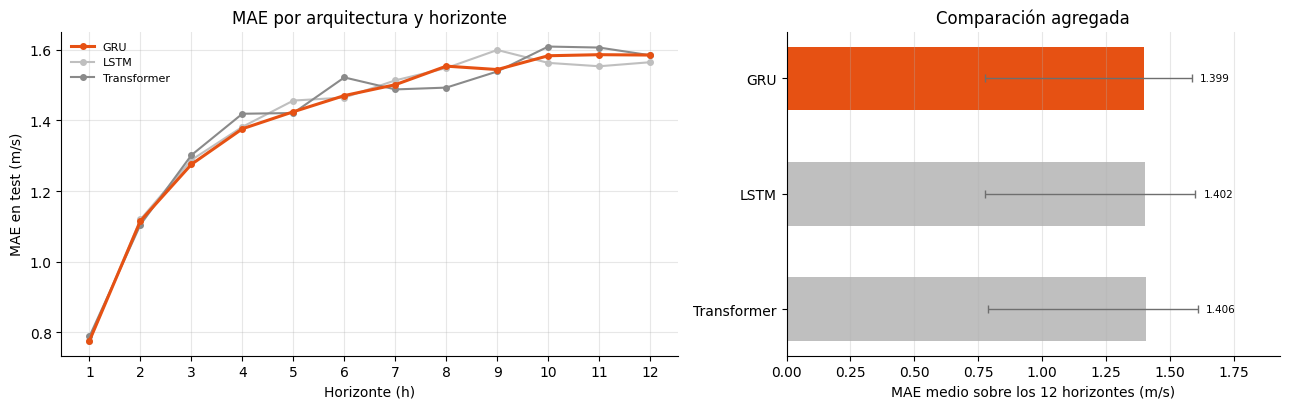

In [3]:
# --- Etapa 1: comparación de arquitecturas en TODOS los horizontes ------------
# Igual que en la selección de familia del notebook 4, comparar las arquitecturas
# en un único horizonte haría la decisión dependiente de ese punto concreto. Una
# arquitectura puede ser superior a corto plazo —donde domina la persistencia de
# la serie— e inferior a plazos largos, donde pesa el pronóstico físico.

def ventana_proxy(H):
    """Ventana preliminar vía Ridge sobre secuencias aplanadas: proxy barato que
    evita tener que entrenar las tres redes con cada ventana candidata."""
    d = preparar_base(H)
    tr_i, va_i, _ = split_temporal_idx(d)
    filas = []
    for W in VENTANAS:
        Xs_tr, Xe_tr, y_tr, _ = construir_secuencias(d, tr_i, W, H)
        Xs_va, Xe_va, y_va, _ = construir_secuencias(d, va_i, W, H)
        if len(y_tr) < 200 or len(y_va) < 50:
            filas.append({'ventana': W, 'MAE_val': np.nan}); continue
        sc = SKScaler().fit(np.hstack([Xs_tr, Xe_tr]))
        m = Ridge(alpha=1.0).fit(sc.transform(np.hstack([Xs_tr, Xe_tr])), y_tr)
        filas.append({'ventana': W,
                      'MAE_val': mean_absolute_error(
                          y_va, m.predict(sc.transform(np.hstack([Xs_va, Xe_va]))))})
    return pd.DataFrame(filas)


def comparar_arquitecturas(H):
    """Entrena las tres arquitecturas en un horizonte con configuración modesta
    e idéntica, de modo que la diferencia sea atribuible a la arquitectura."""
    torch.set_num_threads(N_HILOS_TORCH)
    res_v = ventana_proxy(H)
    W = int(res_v.loc[res_v.MAE_val.idxmin(), 'ventana'])

    (tr, va, te), crudos, sc = datos_para(H, W)
    y_te = crudos[2][2]

    salida = {'H': H, 'ventana': W}
    for nombre in ARQUITECTURAS:
        torch.manual_seed(SEMILLA)
        params = (dict(dim=32, cabezas=4, capas=1, dropout=0.1) if nombre == 'Transformer'
                  else dict(hidden=32, capas=1, dropout=0.0, bidir=False))
        m = construir_modelo(nombre, tr[1].shape[1], params)
        m, val_loss, n_ep = entrenar(m, *tr, *va)
        with torch.no_grad():
            pred = sc[2].inverse_transform(
                m(te[0], te[1]).cpu().numpy().reshape(-1, 1)).ravel()
        salida[nombre] = mean_absolute_error(y_te, pred)
        salida[f'{nombre}_val_loss'] = val_loss
        salida[f'{nombre}_epochs'] = n_ep
    return salida


t0 = time.time()
salidas_arq = Parallel(n_jobs=N_JOBS_HORIZONTE, backend='loky')(
    delayed(comparar_arquitecturas)(H) for H in HORIZONTES)
print(f'Arquitecturas comparadas en {len(HORIZONTES)} horizontes '
      f'({(time.time()-t0)/60:.1f} min)\n')

det_arq = pd.DataFrame(sorted(salidas_arq, key=lambda r: r['H'])).set_index('H')
mae_arq = det_arq[list(ARQUITECTURAS)].T
mae_arq.index.name = 'arquitectura'
display(mae_arq.round(3))

# --- Selección --------------------------------------------------------------
# Dos criterios complementarios, como en el notebook 4: el MAE medio sobre los
# doce horizontes y el número de horizontes en que cada arquitectura resulta la
# mejor. Su coincidencia (o no) indica si la elección es sólida.
resumen_arq = pd.DataFrame({
    'MAE_medio':   mae_arq.mean(axis=1),
    'MAE_min':     mae_arq.min(axis=1),
    'MAE_max':     mae_arq.max(axis=1),
    'veces_mejor': mae_arq.idxmin(axis=0).value_counts()
                          .reindex(mae_arq.index).fillna(0).astype(int),
}).sort_values('MAE_medio')
display(resumen_arq.round(4))

GANADOR_DL = resumen_arq.index[0]
VENTANA_ET1 = int(det_arq.loc[H_REF, 'ventana'])
print(f'Arquitectura ganadora por MAE medio: {GANADOR_DL} '
      f'(mejor en {resumen_arq.loc[GANADOR_DL, "veces_mejor"]} de '
      f'{len(HORIZONTES)} horizontes)')

ganador_h_ref = mae_arq[H_REF].idxmin()
if ganador_h_ref != GANADOR_DL:
    print(f'AVISO: en H={H_REF} h la mejor arquitectura sería {ganador_h_ref}. La '
          f'elección agregada difiere de la que habría producido un único horizonte.')

rango = resumen_arq.MAE_medio.max() - resumen_arq.MAE_medio.min()
print(f'Diferencia entre la mejor y la peor arquitectura: {rango:.4f} m/s '
      f'({100*rango/resumen_arq.MAE_medio.min():.1f} %)')

# Se conserva `tabla_arq` con el formato de la etapa siguiente, ahora referido
# al horizonte de referencia pero con la arquitectura elegida por el agregado.
tabla_arq = pd.DataFrame([
    {'arquitectura': a, 'epochs': int(det_arq.loc[H_REF, f'{a}_epochs']),
     'val_loss': det_arq.loc[H_REF, f'{a}_val_loss'],
     'MAE_test': mae_arq.loc[a, H_REF]}
    for a in ARQUITECTURAS]).sort_values('MAE_test').reset_index(drop=True)

# --- FIGURA -----------------------------------------------------------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2),
                         gridspec_kw={'width_ratios': [1.25, 1]})

grises = ['#BFBFBF', '#8A8A8A']
i_gris = 0
for arq in resumen_arq.index:
    if arq == GANADOR_DL:
        est = dict(color=NARANJA, lw=2.2, marker='o', zorder=5)
    else:
        est = dict(color=grises[i_gris % len(grises)], lw=1.5, marker='o')
        i_gris += 1
    axes[0].plot(mae_arq.columns, mae_arq.loc[arq], markersize=4, label=arq, **est)
axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE en test (m/s)')
axes[0].set_title('MAE por arquitectura y horizonte')
axes[0].set_xticks(list(mae_arq.columns))
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=.3)

orden = resumen_arq.index[::-1]
colores = [NARANJA if a == GANADOR_DL else '#BFBFBF' for a in orden]
err = np.vstack([
    (resumen_arq.loc[orden, 'MAE_medio'] - resumen_arq.loc[orden, 'MAE_min']).values,
    (resumen_arq.loc[orden, 'MAE_max'] - resumen_arq.loc[orden, 'MAE_medio']).values])
axes[1].barh(orden, resumen_arq.loc[orden, 'MAE_medio'], xerr=err, color=colores,
             height=.55, error_kw=dict(ecolor=GRIS, capsize=3, lw=1))
axes[1].set_xlabel('MAE medio sobre los 12 horizontes (m/s)')
axes[1].set_title('Comparación agregada')
axes[1].grid(axis='x', alpha=.3); axes[1].grid(axis='y', visible=False)
for a in orden:
    axes[1].annotate(f"{resumen_arq.loc[a, 'MAE_medio']:.3f}",
                     xy=(resumen_arq.loc[a, 'MAE_max'], a), xytext=(6, 0),
                     textcoords='offset points', va='center', fontsize=7.5)
axes[1].set_xlim(0, resumen_arq.MAE_max.max() * 1.20)

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

plt.tight_layout()

NOMBRE = 'arquitecturas_dl'
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.show()

---
## 3. Etapa 2 — Afinado de las tres arquitecturas

La etapa 1 dejó las tres arquitecturas separadas por un margen muy estrecho, y
con los dos criterios de selección —MAE medio y número de horizontes ganados—
señalando arquitecturas distintas. Afinar únicamente la que quedó primera daría
por resuelta una cuestión que los datos dejan abierta: **una arquitectura peor
sin afinar puede responder mejor al ajuste de sus hiperparámetros**, por lo que
la comparación justa enfrenta a las tres en su mejor versión.

Se realiza por tanto una búsqueda de hiperparámetros independiente para cada
arquitectura y cada horizonte. El espacio incluye la ventana, el tamaño y la
profundidad de la red, el *dropout*, la tasa de aprendizaje y el *weight decay*;
en LSTM y GRU se explora además la bidireccionalidad, y en el Transformer la
dimensión del modelo y el número de cabezas de atención.

> **Coste.** Son $3 \times 12 = 36$ búsquedas de Optuna. Las tareas son
> independientes entre sí, de modo que se reparten entre procesos igual que los
> horizontes en el notebook 4.

In [4]:
# --- Etapa 2: afinado de LAS TRES arquitecturas -------------------------------
# La etapa 1 dejó las tres arquitecturas separadas por un margen inferior a la
# variabilidad por semilla, y con los dos criterios de selección —MAE medio y
# número de horizontes ganados— señalando arquitecturas distintas. Afinar solo
# una de ellas daría por resuelta una cuestión que los datos dejan abierta: es
# posible que una arquitectura peor sin afinar responda mejor al ajuste de sus
# hiperparámetros. Se afinan por tanto las tres y se comparan sus mejores
# versiones, que es la comparación justa.

def espacio_hiperparametros(trial, arquitectura):
    """Espacio de búsqueda específico de cada arquitectura."""
    if arquitectura == 'Transformer':
        dim = trial.suggest_categorical('dim', [16, 32, 64])
        cabezas = trial.suggest_categorical('cabezas', [2, 4])
        if dim % cabezas != 0:          # la dimensión debe repartirse entre cabezas
            raise optuna.TrialPruned()
        return dict(dim=dim, cabezas=cabezas,
                    capas=trial.suggest_int('capas', 1, 2),
                    dropout=trial.suggest_float('dropout', 0.0, 0.3))
    return dict(hidden=trial.suggest_categorical('hidden', [32, 64, 128]),
                capas=trial.suggest_int('capas', 1, 3),
                dropout=trial.suggest_float('dropout', 0.0, 0.3),
                bidir=trial.suggest_categorical('bidir', [False, True]))


def afinar(arquitectura, H):
    """Búsqueda de hiperparámetros de una arquitectura en un horizonte."""
    torch.set_num_threads(N_HILOS_TORCH)

    def objetivo(trial):
        W = trial.suggest_categorical('ventana', VENTANAS)
        (tr, va, _), _, _ = datos_para(H, W)
        params = espacio_hiperparametros(trial, arquitectura)
        lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        wd = trial.suggest_float('wd', 1e-6, 1e-2, log=True)
        torch.manual_seed(SEMILLA)
        m = construir_modelo(arquitectura, tr[1].shape[1], params)
        _, val_loss, _ = entrenar(m, *tr, *va, epochs=60, paciencia=10, lr=lr, wd=wd)
        return val_loss

    est = optuna.create_study(direction='minimize',
                              sampler=optuna.samplers.TPESampler(seed=SEMILLA),
                              pruner=optuna.pruners.MedianPruner(n_warmup_steps=15))
    est.optimize(objetivo, n_trials=TRIALS, show_progress_bar=False)

    bp = est.best_params
    return {'arquitectura': arquitectura, 'H': H,
            'ventana': bp['ventana'], 'lr': bp['lr'], 'wd': bp['wd'],
            'params': {k: v for k, v in bp.items() if k not in ('ventana', 'lr', 'wd')},
            'val_loss': est.best_value}


# Se recorre el producto arquitectura x horizonte. El paralelismo se aplica sobre
# esa lista completa, no solo sobre los horizontes: son 3 x 12 tareas
# independientes entre sí.
tareas = [(a, H) for a in ARQUITECTURAS for H in HORIZONTES]
print(f'Afinando {len(ARQUITECTURAS)} arquitecturas x {len(HORIZONTES)} horizontes '
      f'= {len(tareas)} búsquedas de {TRIALS} trials...')

t0 = time.time()
config_afinada = Parallel(n_jobs=N_JOBS_HORIZONTE, backend='loky')(
    delayed(afinar)(a, H) for a, H in tareas)
print(f'Afinado completado en {(time.time()-t0)/60:.1f} min\n')

# Índice por (arquitectura, horizonte) para la etapa siguiente
CONFIG = {(c['arquitectura'], c['H']): c for c in config_afinada}

resumen_cfg = pd.DataFrame([
    {'arquitectura': c['arquitectura'], 'H': c['H'], 'ventana': c['ventana'],
     'val_loss': c['val_loss'], **c['params']}
    for c in config_afinada]).sort_values(['arquitectura', 'H'])
display(resumen_cfg.round(4))

Afinando 3 arquitecturas x 12 horizontes = 36 búsquedas de 25 trials...


[I 2026-10-06 11:26:30,437] A new study created in memory with name: no-name-00d376b0-3db3-482f-8f1b-c6a8e8445ce6
[I 2026-10-06 11:26:30,445] A new study created in memory with name: no-name-a0c7b015-0430-4d49-a162-b03de47da35c
[I 2026-10-06 11:26:30,450] A new study created in memory with name: no-name-db318bab-b1a2-4d8e-b44d-7f5777586d9e
[I 2026-10-06 11:27:00,908] Trial 0 finished with value: 0.10620121657848358 and parameters: {'ventana': 12, 'hidden': 32, 'capas': 1, 'dropout': 0.2598528437324805, 'bidir': True, 'lr': 0.00010838581269344756, 'wd': 0.007579479953348004}. Best is trial 0 with value: 0.10620121657848358.
[I 2026-10-06 11:27:01,149] Trial 0 finished with value: 0.08730844408273697 and parameters: {'ventana': 12, 'hidden': 32, 'capas': 1, 'dropout': 0.2598528437324805, 'bidir': True, 'lr': 0.00010838581269344756, 'wd': 0.007579479953348004}. Best is trial 0 with value: 0.08730844408273697.
[I 2026-10-06 11:27:30,275] Trial 0 finished with value: 0.05121779814362526 and

Afinado completado en 284.6 min



,arquitectura,H,ventana,val_loss,hidden,capas,dropout,bidir,dim,cabezas
12,GRU,1,24,0.0378,128.0,1,0.2407,True,NaN,NaN
13,GRU,2,6,0.0736,128.0,1,0.1802,False,NaN,NaN
14,GRU,3,6,0.0949,32.0,1,0.2228,True,NaN,NaN
15,GRU,4,24,0.1090,64.0,1,0.2140,False,NaN,NaN
16,GRU,5,6,0.1104,128.0,3,0.1320,False,NaN,NaN
17,GRU,6,6,0.1114,128.0,2,0.0874,False,NaN,NaN
18,GRU,7,6,0.1166,128.0,1,0.1526,False,NaN,NaN
19,GRU,8,6,0.1202,64.0,2,0.1718,False,NaN,NaN
20,GRU,9,6,0.1220,32.0,3,0.2023,False,NaN,NaN
21,GRU,10,24,0.1222,64.0,2,0.2614,False,NaN,NaN


---
## 4. Etapa 3 — Comparación de las tres arquitecturas afinadas

Cada arquitectura se entrena ahora con **su** configuración óptima en cada
horizonte, y con un **ensemble de tres semillas** cuyas predicciones se
promedian, lo que reduce la varianza asociada a la inicialización aleatoria sin
necesidad de repetir la búsqueda de hiperparámetros.

La comparación final enfrenta así a las tres arquitecturas en su mejor versión.
Se aplican los dos criterios ya empleados —MAE medio sobre los doce horizontes y
número de horizontes en que cada una resulta la mejor— y se advierte
explícitamente si discrepan, por ser ese desacuerdo indicio de equivalencia
entre arquitecturas.

De la ganadora se conservan las predicciones y la configuración, que alimentan
las secciones siguientes (comparación con ML, interpretabilidad y guardado).

36 evaluaciones en 33.4 min



H,1,2,3,4,5,6,7,8,9,10,11,12
arquitectura,,,,,,,,,,,,
GRU,0.774,1.105,1.265,1.361,1.402,1.455,1.491,1.525,1.532,1.552,1.521,1.588
LSTM,0.772,1.112,1.272,1.363,1.438,1.448,1.495,1.534,1.536,1.535,1.571,1.571
Transformer,0.768,1.108,1.281,1.353,1.426,1.434,1.483,1.491,1.537,1.530,1.545,1.551


,MAE_medio,MAE_min,MAE_max,veces_mejor
arquitectura,,,,
Transformer,1.3756,0.7683,1.5507,7
GRU,1.3809,0.7743,1.5883,5
LSTM,1.3872,0.7719,1.5709,0


Arquitectura ganadora tras el afinado: Transformer (mejor en 7 de 12 horizontes)
Diferencia entre la mejor y la peor: 0.0116 m/s (0.84 %)

Configuración de Transformer en H=12: ventana=6, lr=1.18e-03, wd=4.03e-04, {'dim': 64, 'cabezas': 2, 'capas': 2, 'dropout': 0.1051289560506137}

Ganancia del ensemble frente a la mejor semilla individual:
  H= 1  mejor individual=0.765  ensemble=0.768  -0.4%
  H= 2  mejor individual=1.115  ensemble=1.108  +0.6%
  H= 3  mejor individual=1.278  ensemble=1.281  -0.2%
  H= 4  mejor individual=1.342  ensemble=1.353  -0.8%
  H= 5  mejor individual=1.420  ensemble=1.426  -0.4%
  H= 6  mejor individual=1.437  ensemble=1.434  +0.2%
  H= 7  mejor individual=1.478  ensemble=1.483  -0.3%
  H= 8  mejor individual=1.491  ensemble=1.491  +0.0%
  H= 9  mejor individual=1.531  ensemble=1.537  -0.4%
  H=10  mejor individual=1.530  ensemble=1.530  +0.0%
  H=11  mejor individual=1.547  ensemble=1.545  +0.1%
  H=12  mejor individual=1.560  ensemble=1.551  +0.6%
figura g

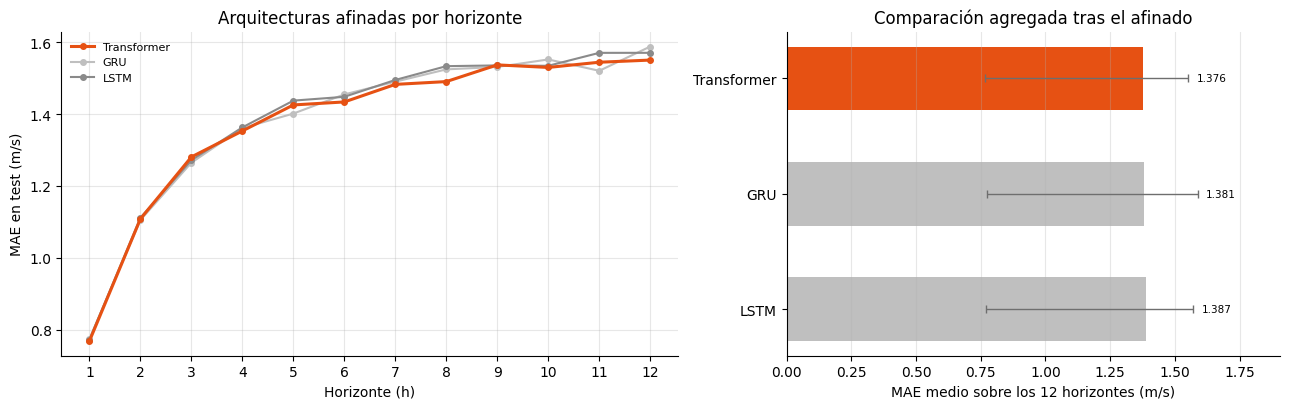

In [5]:
# --- Etapa 3: las tres arquitecturas afinadas en todos los horizontes ---------
# Cada arquitectura se entrena con SU configuración óptima en cada horizonte y
# con ensemble de semillas, de modo que la comparación final enfrenta a las tres
# en su mejor versión.

def evaluar_afinada(arquitectura, H):
    """Ensemble de semillas de una arquitectura afinada en un horizonte."""
    torch.set_num_threads(N_HILOS_TORCH)
    t0 = time.time()
    cfg = CONFIG[(arquitectura, H)]
    (tr, va, te), crudos, sc = datos_para(H, cfg['ventana'])
    y_te, idx_te = crudos[2][2], crudos[2][3]

    preds = []
    for s in range(N_SEMILLAS_ENSEMBLE):
        torch.manual_seed(SEMILLA + s)
        m = construir_modelo(arquitectura, tr[1].shape[1], cfg['params'])
        m, _, _ = entrenar(m, *tr, *va, lr=cfg['lr'], wd=cfg['wd'])
        with torch.no_grad():
            preds.append(sc[2].inverse_transform(
                m(te[0], te[1]).cpu().numpy().reshape(-1, 1)).ravel())

    mae_semillas = [mean_absolute_error(y_te, p) for p in preds]
    ensemble = np.mean(preds, axis=0)
    return {'arquitectura': arquitectura, 'H': H, 'ventana': cfg['ventana'],
            'MAE': mean_absolute_error(y_te, ensemble),
            'RMSE': np.sqrt(mean_squared_error(y_te, ensemble)),
            'n_test': len(y_te), 'MAE_semillas': mae_semillas,
            'segundos': time.time()-t0,
            'pred': pd.Series(ensemble, index=idx_te, name=arquitectura)}


t_ini = time.time()
salidas = Parallel(n_jobs=N_JOBS_HORIZONTE, backend='loky')(
    delayed(evaluar_afinada)(a, H) for a in ARQUITECTURAS for H in HORIZONTES)
print(f'{len(salidas)} evaluaciones en {(time.time()-t_ini)/60:.1f} min\n')

det = pd.DataFrame([{k: v for k, v in s.items() if k != 'pred'} for s in salidas])
mae_afinado = det.pivot(index='arquitectura', columns='H', values='MAE')
display(mae_afinado.round(3))

# --- Selección de la arquitectura final --------------------------------------
resumen_final = pd.DataFrame({
    'MAE_medio':   mae_afinado.mean(axis=1),
    'MAE_min':     mae_afinado.min(axis=1),
    'MAE_max':     mae_afinado.max(axis=1),
    'veces_mejor': mae_afinado.idxmin(axis=0).value_counts()
                              .reindex(mae_afinado.index).fillna(0).astype(int),
}).sort_values('MAE_medio')
display(resumen_final.round(4))

GANADOR_DL = resumen_final.index[0]
rango = resumen_final.MAE_medio.max() - resumen_final.MAE_medio.min()

print(f'Arquitectura ganadora tras el afinado: {GANADOR_DL} '
      f'(mejor en {resumen_final.loc[GANADOR_DL, "veces_mejor"]} de {len(HORIZONTES)} horizontes)')
print(f'Diferencia entre la mejor y la peor: {rango:.4f} m/s '
      f'({100*rango/resumen_final.MAE_medio.min():.2f} %)')

ganador_veces = resumen_final.veces_mejor.idxmax()
if ganador_veces != GANADOR_DL:
    print(f'AVISO: por número de horizontes ganados la mejor sería {ganador_veces}. '
          f'Los dos criterios no coinciden, indicio de que las arquitecturas son '
          f'equivalentes para este problema.')

# --- Resultados de la arquitectura elegida, para las secciones siguientes -----
resultados_finales, predicciones_finales = [], {}
for s in sorted([x for x in salidas if x['arquitectura'] == GANADOR_DL],
                key=lambda r: r['H']):
    predicciones_finales[s['H']] = s['pred']
    resultados_finales.append({'H': s['H'], 'modelo': GANADOR_DL, 'ventana': s['ventana'],
                               'MAE': s['MAE'], 'RMSE': s['RMSE'],
                               'n_test': s['n_test'], 'MAE_semillas': s['MAE_semillas']})

tabla_dl = pd.DataFrame(resultados_finales)
cfg_ganador = CONFIG[(GANADOR_DL, H_REF)]
W_OPT, LR_FINAL, WD_FINAL = cfg_ganador['ventana'], cfg_ganador['lr'], cfg_ganador['wd']
PARAMS_FIN = cfg_ganador['params']

print(f'\nConfiguración de {GANADOR_DL} en H={H_REF}: ventana={W_OPT}, '
      f'lr={LR_FINAL:.2e}, wd={WD_FINAL:.2e}, {PARAMS_FIN}')

print('\nGanancia del ensemble frente a la mejor semilla individual:')
for r in resultados_finales:
    mejor = min(r['MAE_semillas'])
    print(f"  H={r['H']:>2}  mejor individual={mejor:.3f}  ensemble={r['MAE']:.3f}  "
          f"{100*(mejor-r['MAE'])/mejor:+.1f}%")

# --- FIGURA: las tres arquitecturas afinadas ---------------------------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2),
                         gridspec_kw={'width_ratios': [1.25, 1]})

grises = ['#BFBFBF', '#8A8A8A']
i_gris = 0
for arq in resumen_final.index:
    if arq == GANADOR_DL:
        est = dict(color=NARANJA, lw=2.2, marker='o', zorder=5)
    else:
        est = dict(color=grises[i_gris % len(grises)], lw=1.5, marker='o'); i_gris += 1
    axes[0].plot(mae_afinado.columns, mae_afinado.loc[arq], markersize=4,
                 label=arq, **est)
axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE en test (m/s)')
axes[0].set_title('Arquitecturas afinadas por horizonte')
axes[0].set_xticks(list(mae_afinado.columns))
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=.3)

orden = resumen_final.index[::-1]
colores = [NARANJA if a == GANADOR_DL else '#BFBFBF' for a in orden]
err = np.vstack([
    (resumen_final.loc[orden, 'MAE_medio'] - resumen_final.loc[orden, 'MAE_min']).values,
    (resumen_final.loc[orden, 'MAE_max'] - resumen_final.loc[orden, 'MAE_medio']).values])
axes[1].barh(orden, resumen_final.loc[orden, 'MAE_medio'], xerr=err, color=colores,
             height=.55, error_kw=dict(ecolor=GRIS, capsize=3, lw=1))
axes[1].set_xlabel('MAE medio sobre los 12 horizontes (m/s)')
axes[1].set_title('Comparación agregada tras el afinado')
axes[1].grid(axis='x', alpha=.3); axes[1].grid(axis='y', visible=False)
for a in orden:
    axes[1].annotate(f"{resumen_final.loc[a, 'MAE_medio']:.3f}",
                     xy=(resumen_final.loc[a, 'MAE_max'], a), xytext=(6, 0),
                     textcoords='offset points', va='center', fontsize=7.5)
axes[1].set_xlim(0, resumen_final.MAE_max.max() * 1.20)

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

plt.tight_layout()

NOMBRE = 'arquitecturas_afinadas'
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.show()

---
## 5. Comparación con ML y baselines

Comparación orientativa, con cada modelo sobre su propia muestra de evaluación; la definitiva, sobre la intersección horaria común, se hace en el notebook 6.

* Si el DL **mejora** claramente al ML, hay estructura temporal que los árboles no captaban.
* Si **iguala** sin superar, confirma la hipótesis inicial: dependencias cortas y relación
  aditiva, sin margen donde la ventaja estructural del DL se manifieste.
* Si **empeora**, lo más probable con miles (no millones) de observaciones es que el volumen
  sea insuficiente para que una red generalice mejor que un ensemble de árboles.

Cualquiera de los tres es un resultado válido para el objetivo 2: el objetivo es la
comparación sistemática, no que el DL gane.

,Transformer (DL),XGBoost (ML),HARMONIE bruto,SARIMAX (+HARMONIE)
H,,,,
1,0.768,0.767,2.751,0.792
2,1.108,1.099,2.756,1.182
3,1.281,1.256,2.764,1.431
4,1.353,1.357,2.775,1.647
5,1.426,1.406,2.778,1.829
6,1.434,1.439,2.780,2.023
7,1.483,1.469,2.785,2.168
8,1.491,1.486,2.791,2.362
9,1.537,1.504,2.791,2.465


figura guardada: figuras/dl_vs_ml.pdf


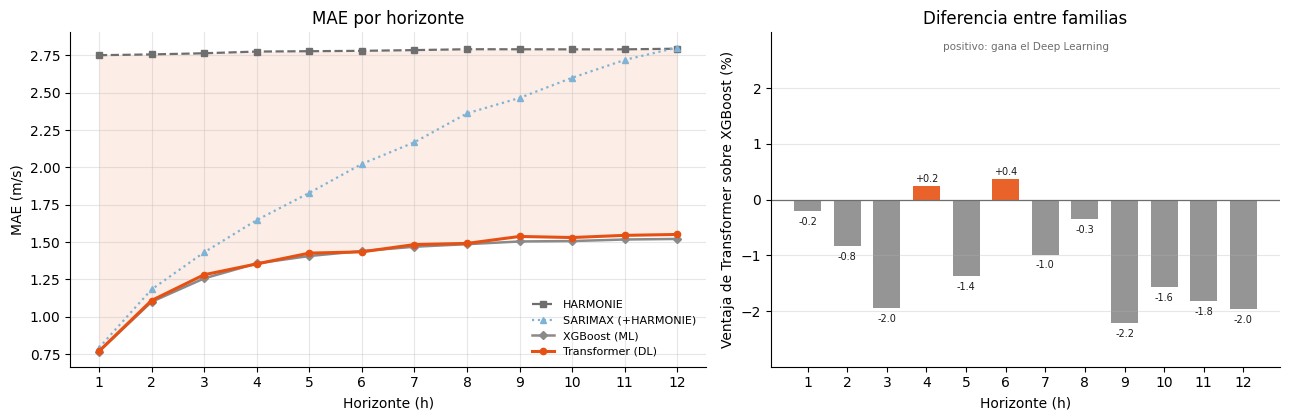

Ventaja de Transformer (DL) sobre XGBoost (ML), en % (positivo = gana el DL):
H
1    -0.2
2    -0.8
3    -2.0
4     0.2
5    -1.4
6     0.4
7    -1.0
8    -0.3
9    -2.2
10   -1.6
11   -1.8
12   -2.0

Diferencia media: -1.06 %  |  máxima a favor del DL: +0.36 %  |  máxima a favor del ML: -2.22 %


In [6]:
comp = tabla_dl.set_index('H')['MAE'].rename(f'{GANADOR_DL} (DL)').to_frame()

if (RUTA/'ml_mejor_modelo.json').exists():
    with open(RUTA/'ml_mejor_modelo.json') as f:
        ml_prev = json.load(f)
    comp = comp.join(pd.DataFrame(ml_prev['metricas']).set_index('H')['MAE'].rename('XGBoost (ML)'))

if (RUTA/'baselines_metricas.csv').exists():
    bl = pd.read_csv(RUTA/'baselines_metricas.csv')
    bl = bl[bl.modelo.isin(['HARMONIE bruto', 'SARIMAX (+HARMONIE)'])]
    comp = comp.join(bl.pivot(index='H', columns='modelo', values='MAE'))

display(comp.round(3))

# --- FIGURA: Deep Learning frente a Machine Learning y baselines --------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
AZUL    = '#7FB3D5'

COL_DL = f'{GANADOR_DL} (DL)'
COL_ML = 'XGBoost (ML)'

# El naranja se reserva para el modelo de Deep Learning, protagonista de esta
# figura; el ML se dibuja en un gris oscuro para que la comparación entre ambos
# sea inmediata, y los baselines quedan en gris claro y azul al fondo.
ESTILO_MOD = {
    'HARMONIE bruto':      dict(color=GRIS,      ls='--', marker='s', lw=1.6),
    'SARIMAX (+HARMONIE)': dict(color=AZUL,      ls=':',  marker='^', lw=1.6),
    COL_ML:                dict(color='#8A8A8A', ls='-',  marker='D', lw=1.8),
    COL_DL:                dict(color=NARANJA,   ls='-',  marker='o', lw=2.2),
}
ETIQUETA = {'HARMONIE bruto': 'HARMONIE', 'SARIMAX (+HARMONIE)': 'SARIMAX (+HARMONIE)'}

hay_ml = COL_ML in comp.columns
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# (a) MAE por horizonte -------------------------------------------------------
orden = ['HARMONIE bruto', 'SARIMAX (+HARMONIE)', COL_ML, COL_DL]
for modelo in [m for m in orden if m in comp.columns]:
    axes[0].plot(comp.index, comp[modelo], markersize=4.5,
                 label=ETIQUETA.get(modelo, modelo), **ESTILO_MOD[modelo])

# El área sombreada visualiza la corrección que aporta el modelo sobre el
# pronóstico operativo, que es la magnitud que justifica el trabajo.
if 'HARMONIE bruto' in comp.columns:
    axes[0].fill_between(comp.index, comp[COL_DL], comp['HARMONIE bruto'],
                         color=NARANJA, alpha=.10, lw=0, zorder=0)

axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE (m/s)')
axes[0].set_title('MAE por horizonte')
axes[0].set_xticks(list(comp.index))
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=.3)

# (b) Diferencia frente al Machine Learning -----------------------------------
# La comparación relevante de esta sección no es contra el pronóstico bruto
# —ya documentada en el notebook 4— sino entre las dos familias de aprendizaje.
if hay_ml:
    dif = 100*(comp[COL_ML] - comp[COL_DL])/comp[COL_ML]
    colores = [NARANJA if v > 0 else '#8A8A8A' for v in dif.values]
    barras = axes[1].bar(comp.index, dif.values, color=colores, alpha=.9, width=.68)
    axes[1].axhline(0, color=GRIS, lw=.9)
    axes[1].set_xlabel('Horizonte (h)')
    axes[1].set_ylabel(f'Ventaja de {GANADOR_DL} sobre XGBoost (%)')
    axes[1].set_title('Diferencia entre familias')
    axes[1].set_xticks(list(comp.index))
    axes[1].grid(axis='y', alpha=.3)

    margen = max(abs(dif.min()), abs(dif.max())) * 1.35
    axes[1].set_ylim(-margen, margen)
    for barra, valor in zip(barras, dif.values):
        axes[1].annotate(f'{valor:+.1f}',
                         xy=(barra.get_x() + barra.get_width()/2, valor),
                         xytext=(0, 3 if valor >= 0 else -10), textcoords='offset points',
                         ha='center', fontsize=7, color='#1A1A1A')

    # Las diferencias son de décimas de punto porcentual: conviene decirlo en la
    # propia figura para que no se lean como una ventaja sustantiva.
    axes[1].annotate('positivo: gana el Deep Learning',
                     xy=(0.5, 0.97), xycoords='axes fraction',
                     ha='center', va='top', fontsize=7.5, color=GRIS)
else:
    axes[1].axis('off')

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

plt.tight_layout()

NOMBRE = 'dl_vs_ml'
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.show()

if hay_ml:
    print(f'Ventaja de {GANADOR_DL} (DL) sobre XGBoost (ML), en % (positivo = gana el DL):')
    print(dif.round(1).to_string())
    print(f'\nDiferencia media: {dif.mean():+.2f} %  |  '
          f'máxima a favor del DL: {dif.max():+.2f} %  |  '
          f'máxima a favor del ML: {dif.min():+.2f} %')

---
### 5.1 Variabilidad por semilla de inicialización

Las diferencias entre arquitecturas, y entre el Deep Learning y XGBoost, son de
centésimas de m/s. Para saber si son interpretables hay que compararlas con la
variabilidad que introduce **solo** la semilla de inicialización, manteniendo fijos
los datos, la ventana y todos los hiperparámetros.

Se reentrena la arquitectura ganadora con su configuración afinada en cada horizonte
y con `N_SEMILLAS_VAR` semillas distintas, evaluando cada modelo **individualmente**
(sin promediar) sobre el mismo conjunto de test. El rango entre la mejor y la peor
semilla es la escala de referencia: una diferencia entre modelos inferior a ese rango
no puede atribuirse con seguridad al modelo, porque otra semilla podría invertirla.

Las tres primeras semillas coinciden con las del ensemble de la etapa 3
(`SEMILLA + 0, 1, 2`), lo que sirve además como comprobación de reproducibilidad.


12 horizontes x 5 semillas = 60 entrenamientos en 15.5 min



,semilla_0,semilla_1,semilla_2,semilla_3,semilla_4,MAE_min,MAE_max,rango,desv
H,,,,,,,,,
1,0.765,0.780,0.778,0.773,0.776,0.765,0.780,0.015,0.006
2,1.115,1.127,1.134,1.114,1.112,1.112,1.134,0.023,0.010
3,1.283,1.278,1.307,1.297,1.287,1.278,1.307,0.029,0.012
4,1.342,1.387,1.353,1.375,1.363,1.342,1.387,0.045,0.018
5,1.420,1.449,1.441,1.427,1.432,1.420,1.449,0.029,0.011
6,1.443,1.440,1.437,1.454,1.447,1.437,1.454,0.017,0.007
7,1.484,1.478,1.516,1.498,1.461,1.461,1.516,0.056,0.021
8,1.491,1.492,1.510,1.541,1.528,1.491,1.541,0.050,0.022
9,1.531,1.558,1.538,1.561,1.554,1.531,1.561,0.029,0.013


Reproducibilidad (semillas 0-2 frente a la etapa 3): discrepancia máxima 0.00e+00 m/s


,rango_semillas,gap_arquitecturas,dif_DL_ML,gap_arq / rango,dif_ML / rango
H,,,,,
1,0.015,0.006,0.002,0.408,0.105
2,0.023,0.006,0.009,0.285,0.404
3,0.029,0.016,0.025,0.553,0.848
4,0.045,0.010,0.003,0.221,0.073
5,0.029,0.036,0.019,1.239,0.666
6,0.017,0.021,0.005,1.220,0.305
7,0.056,0.012,0.014,0.222,0.261
8,0.050,0.043,0.005,0.858,0.102
9,0.029,0.006,0.033,0.196,1.140



Rango por semilla: medio 0.036 m/s | máximo 0.063 m/s (H=11) | mínimo 0.015 m/s
Desviación típica entre semillas: media 0.014 m/s
Horizontes en que la separación entre arquitecturas es menor que el rango por semilla: 9 de 12
Horizontes en que |DL - ML| es menor que el rango por semilla: 10 de 12
Máxima |DL - ML|: 0.033 m/s (H=9), rango por semilla en ese horizonte: 0.029 m/s
|GRU - LSTM| en MAE medio (sin afinar): 0.0030 m/s  ->  21 veces menor que el rango máximo por semilla
|GRU - LSTM| en MAE medio (afinadas): 0.0063 m/s  ->  10 veces menor que el rango máximo por semilla
Paso C -> E del estudio de eliminación (0.008 m/s): 7.8 veces menor que el rango máximo por semilla

Guardado dl_variabilidad_semillas.csv
figura guardada: figuras/variabilidad_semillas.pdf


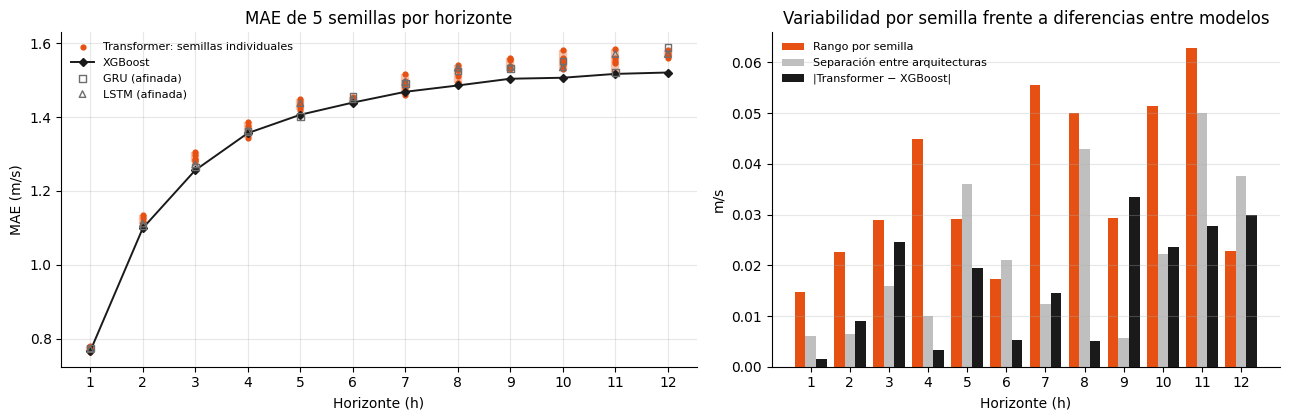

In [7]:
# --- Variabilidad por semilla del modelo ganador ------------------------------
# Se reentrena GANADOR_DL con SU configuración afinada en cada horizonte, variando
# únicamente la semilla. Cada semilla se evalúa por separado (no se promedia): lo
# que interesa es la dispersión entre ellas, no el mejor resultado.

N_SEMILLAS_VAR = 5
DIF_ABLACION_CE = 0.008   # m/s, paso C -> E del estudio de eliminación (notebook 2)

def entrenar_semillas(H):
    """Entrena GANADOR_DL en el horizonte H con N_SEMILLAS_VAR semillas."""
    torch.set_num_threads(N_HILOS_TORCH)
    cfg = CONFIG[(GANADOR_DL, H)]
    (tr, va, te), crudos, sc = datos_para(H, cfg['ventana'])
    y_te = crudos[2][2]
    maes = []
    for s in range(N_SEMILLAS_VAR):
        torch.manual_seed(SEMILLA + s)
        m = construir_modelo(GANADOR_DL, tr[1].shape[1], cfg['params'])
        m, _, _ = entrenar(m, *tr, *va, lr=cfg['lr'], wd=cfg['wd'])
        with torch.no_grad():
            p = sc[2].inverse_transform(
                m(te[0], te[1]).cpu().numpy().reshape(-1, 1)).ravel()
        maes.append(mean_absolute_error(y_te, p))
    return {'H': H, **{f'semilla_{s}': v for s, v in enumerate(maes)}}

t0 = time.time()
salidas_var = Parallel(n_jobs=N_JOBS_HORIZONTE, backend='loky')(
    delayed(entrenar_semillas)(H) for H in HORIZONTES)
print(f'{len(HORIZONTES)} horizontes x {N_SEMILLAS_VAR} semillas = '
      f'{len(HORIZONTES)*N_SEMILLAS_VAR} entrenamientos en {(time.time()-t0)/60:.1f} min\n')

var = pd.DataFrame(salidas_var).set_index('H').sort_index()
cols_s = [c for c in var.columns if c.startswith('semilla_')]
var['MAE_min'] = var[cols_s].min(axis=1)
var['MAE_max'] = var[cols_s].max(axis=1)
var['rango']   = var.MAE_max - var.MAE_min
var['desv']    = var[cols_s].std(axis=1, ddof=1)
display(var.round(3))

# --- Comprobación de reproducibilidad frente al ensemble de la etapa 3 --------
ref = {r['H']: r['MAE_semillas'] for r in resultados_finales}
n_comun = min(N_SEMILLAS_VAR, N_SEMILLAS_ENSEMBLE)
dif_rep = max(abs(var.loc[H, f'semilla_{s}'] - ref[H][s])
              for H in HORIZONTES for s in range(n_comun))
print(f'Reproducibilidad (semillas 0-{n_comun-1} frente a la etapa 3): '
      f'discrepancia máxima {dif_rep:.2e} m/s'
      + ('' if dif_rep < 1e-3 else
         '   <-- AVISO: el entrenamiento no es determinista en este entorno'))

# --- Escalas de comparación ---------------------------------------------------
# (1) separación entre las tres arquitecturas afinadas en cada horizonte
gap_arq = (mae_afinado.max(axis=0) - mae_afinado.min(axis=0)).rename('gap_arquitecturas')
# (2) diferencia absoluta entre el Deep Learning y XGBoost en cada horizonte
COL_DL, COL_ML = f'{GANADOR_DL} (DL)', 'XGBoost (ML)'
hay_ml = COL_ML in comp.columns
dif_ml = ((comp[COL_DL] - comp[COL_ML]).abs().rename('dif_DL_ML')
          if hay_ml else pd.Series(np.nan, index=var.index, name='dif_DL_ML'))

escalas = pd.concat([var['rango'].rename('rango_semillas'), gap_arq, dif_ml], axis=1)
escalas['gap_arq / rango'] = escalas.gap_arquitecturas / escalas.rango_semillas
escalas['dif_ML / rango']  = escalas.dif_DL_ML / escalas.rango_semillas
display(escalas.round(3))

h_max = var.rango.idxmax()
print(f'\nRango por semilla: medio {var.rango.mean():.3f} m/s | '
      f'máximo {var.rango.max():.3f} m/s (H={h_max}) | mínimo {var.rango.min():.3f} m/s')
print(f'Desviación típica entre semillas: media {var.desv.mean():.3f} m/s')
print(f'Horizontes en que la separación entre arquitecturas es menor que el rango '
      f'por semilla: {(escalas.gap_arquitecturas < escalas.rango_semillas).sum()} de {len(escalas)}')
if hay_ml:
    print(f'Horizontes en que |DL - ML| es menor que el rango por semilla: '
          f'{(escalas.dif_DL_ML < escalas.rango_semillas).sum()} de {len(escalas)}')
    print(f'Máxima |DL - ML|: {escalas.dif_DL_ML.max():.3f} m/s '
          f'(H={escalas.dif_DL_ML.idxmax()}), rango por semilla en ese horizonte: '
          f'{var.loc[escalas.dif_DL_ML.idxmax(), "rango"]:.3f} m/s')

# Diferencias en MAE medio entre arquitecturas, antes y después del afinado
for etq, res in [('sin afinar', resumen_arq), ('afinadas', resumen_final)]:
    d = abs(res.loc['GRU', 'MAE_medio'] - res.loc['LSTM', 'MAE_medio'])
    print(f'|GRU - LSTM| en MAE medio ({etq}): {d:.4f} m/s  ->  '
          f'{var.rango.max()/d:.0f} veces menor que el rango máximo por semilla')
print(f'Paso C -> E del estudio de eliminación ({DIF_ABLACION_CE} m/s): '
      f'{var.rango.max()/DIF_ABLACION_CE:.1f} veces menor que el rango máximo por semilla')

var.join(escalas.drop(columns='rango_semillas')).to_csv(RUTA/'dl_variabilidad_semillas.csv')
print('\nGuardado dl_variabilidad_semillas.csv')

# --- FIGURA: variabilidad por semilla frente a las diferencias entre modelos ---
NARANJA, GRIS = '#E65113', '#6E6E6E'
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# (a) MAE de cada semilla por horizonte, con su rango y los otros modelos
ax = axes[0]
for H in var.index:
    ax.vlines(H, var.loc[H, 'MAE_min'], var.loc[H, 'MAE_max'],
              color=NARANJA, alpha=.35, lw=6, zorder=1)
    ax.scatter([H]*len(cols_s), var.loc[H, cols_s], s=12, color=NARANJA,
               zorder=3, label=f'{GANADOR_DL}: semillas individuales' if H == var.index[0] else None)
if hay_ml:
    ax.plot(comp.index, comp[COL_ML], color='#1A1A1A', ls='-', marker='D',
            markersize=4, lw=1.4, zorder=4, label='XGBoost')
otras = [a for a in mae_afinado.index if a != GANADOR_DL]
for a, mk in zip(otras, ['s', '^']):
    ax.scatter(mae_afinado.columns, mae_afinado.loc[a], marker=mk, s=22,
               facecolors='none', edgecolors=GRIS, zorder=4, label=f'{a} (afinada)')
ax.set_xlabel('Horizonte (h)'); ax.set_ylabel('MAE (m/s)')
ax.set_title(f'MAE de {N_SEMILLAS_VAR} semillas por horizonte')
ax.set_xticks(list(var.index)); ax.grid(alpha=.3)
ax.legend(fontsize=8, frameon=False)

# (b) Rango por semilla frente a las diferencias entre modelos
ax = axes[1]
x, ancho = np.arange(len(escalas)), .27
ax.bar(x - ancho, escalas.rango_semillas, ancho, color=NARANJA, label='Rango por semilla')
ax.bar(x, escalas.gap_arquitecturas, ancho, color='#BFBFBF', label='Separación entre arquitecturas')
if hay_ml:
    ax.bar(x + ancho, escalas.dif_DL_ML, ancho, color='#1A1A1A',
           label=f'|{GANADOR_DL} − XGBoost|')
ax.set_xticks(x); ax.set_xticklabels(escalas.index)
ax.set_xlabel('Horizonte (h)'); ax.set_ylabel('m/s')
ax.set_title('Variabilidad por semilla frente a diferencias entre modelos')
ax.grid(axis='y', alpha=.3); ax.legend(fontsize=8, frameon=False)

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
plt.tight_layout()

NOMBRE = 'variabilidad_semillas'
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')
plt.show()


---
### 5.2 Un episodio concreto

Las métricas agregadas resumen miles de horas y ocultan el comportamiento de cada
modelo ante un evento determinado. Se reconstruye aquí un caso de uso operativo
completo: se fija un instante de decisión y se representan las horas previas
observadas —la información de que dispone el operador— junto con lo que cada
modelo pronostica para las doce horas siguientes.

Conviene precisar que cada punto de la curva de predicción procede de un modelo
distinto: el valor a seis horas es la predicción del modelo entrenado a horizonte
6 h, no un paso intermedio de una predicción a doce horas. Ello reproduce
fielmente el uso operativo, en el que cada horizonte dispone de su propio modelo.

Se representa junto al Deep Learning el modelo de Machine Learning del notebook 4
y el pronóstico físico sin corregir, de modo que el ejemplo muestre tanto la
corrección aportada sobre HARMONIE-AROME como la diferencia —previsiblemente
escasa— entre las dos familias de aprendizaje.

Instante de decisión: 2022-08-03 06:00:00
Horizontes con predicción disponible: 12 de 12


,real,H,momento,Transformer,HARMONIE,XGBoost,err Transformer,err XGBoost,err HARMONIE
ts,,,,,,,,,
2022-08-03 01:00:00,16.78,-5,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 02:00:00,17.16,-4,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 03:00:00,16.90,-3,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 04:00:00,15.90,-2,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 05:00:00,16.67,-1,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 06:00:00,15.18,0,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 07:00:00,14.12,1,predicción,14.85,11.14,14.64,0.73,0.52,2.98
2022-08-03 08:00:00,14.18,2,predicción,14.66,10.58,14.82,0.48,0.64,3.60
2022-08-03 09:00:00,14.29,3,predicción,14.46,10.34,14.42,0.17,0.13,3.95


figura guardada: figuras/episodio_dl.pdf


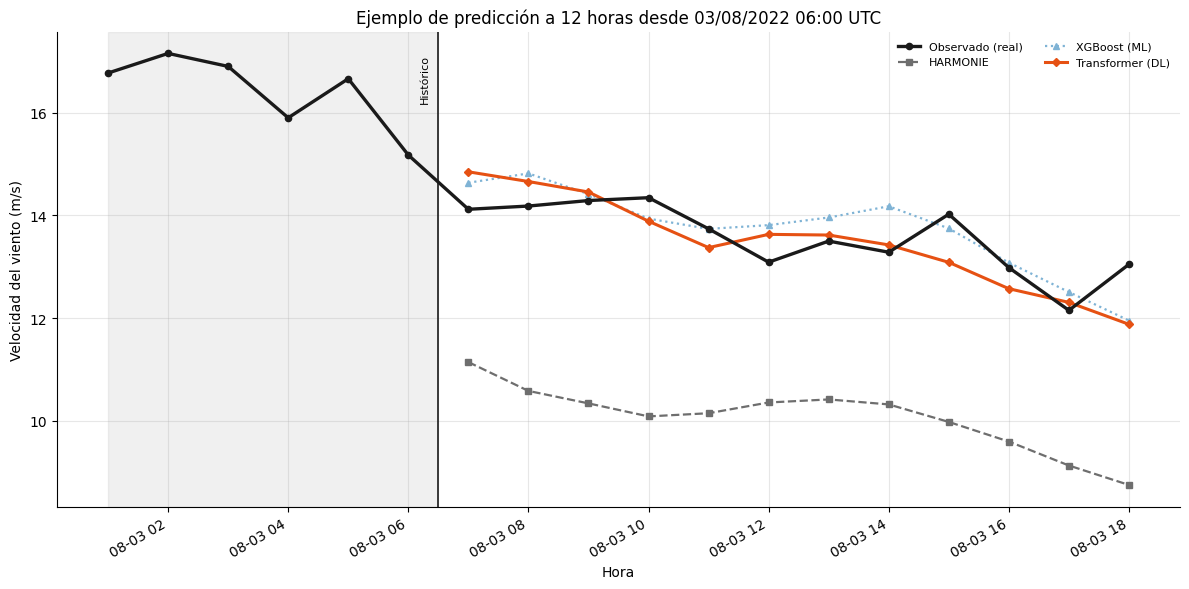

MAE en este episodio (12 h):
  Transformer (DL)        0.47 m/s
  XGBoost (ML)            0.47 m/s
  HARMONIE                3.50 m/s
  (promedio global de Transformer sobre todo el test: 1.38 m/s)

El viento NO desciende del umbral (11.5 m/s) en todo el episodio.
Un modelo que sí lo cruzase generaría una desactivación improcedente:
  Transformer (DL)       no cruza
  XGBoost (ML)           no cruza
  HARMONIE               cruza en h=1 (falsa alarma)

(un episodio concreto puede desviarse del promedio: se muestra con
 propósito ilustrativo, no como evidencia de rendimiento)


In [8]:
# --- Configuración del ejemplo ------------------------------------------------
N_PREVIAS = 6      # horas de historia observada previa al instante de decisión
UMBRAL = 11.5      # m/s, umbral de activación de seguridad

# Instante de decisión del ejemplo. Con None se elige automáticamente; para
# examinar un episodio concreto, indíquese su fecha:
#     T0_MANUAL = pd.Timestamp(2022, 8, 3, 6)
# El índice del dataset no lleva zona horaria, así que la marca tampoco debe
# llevarla. Si la fecha indicada no tiene predicción en los doce horizontes, la
# celda avisa y sugiere las más próximas que sí la tienen.
T0_MANUAL = pd.Timestamp(2022, 8, 3, 6)

NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
NEGRO   = '#1A1A1A'
AZUL    = '#7FB3D5'


def instantes_completos():
    """Instantes de decisión con predicción disponible en los doce horizontes."""
    comun = None
    for H in HORIZONTES:
        serie = predicciones_finales.get(H)
        if serie is None:
            return []
        t0 = set(serie.dropna().index - pd.Timedelta(hours=H))
        comun = t0 if comun is None else comun & t0
    return sorted(comun or [])


def elegir_episodio():
    """Episodio de mayor recorrido de viento que además cruce el umbral: es
    donde la calidad del pronóstico decide la actuación del sistema."""
    recorrido = {}
    for t0 in instantes_completos():
        fut = base[OBJ].reindex(pd.date_range(t0 + pd.Timedelta(hours=1),
                                              t0 + pd.Timedelta(hours=max(HORIZONTES)),
                                              freq='h'))
        if fut.notna().all() and (fut >= UMBRAL).any() and (fut < UMBRAL).any():
            recorrido[t0] = fut.max() - fut.min()
    if not recorrido:
        candidatos = instantes_completos()
        return candidatos[len(candidatos)//2] if candidatos else None
    return max(recorrido, key=recorrido.get)


def resolver_t0():
    """Devuelve el instante de decisión, validando el elegido a mano."""
    validos = instantes_completos()
    if T0_MANUAL is None:
        return elegir_episodio()

    t0 = pd.Timestamp(T0_MANUAL)
    if t0.tzinfo is not None:          # el índice del dataset es naive
        t0 = t0.tz_localize(None)
    if t0 in set(validos):
        return t0

    print(f'AVISO: {t0} no tiene predicción en los doce horizontes.')
    if validos:
        cercanos = sorted(validos, key=lambda x: abs(x - t0))[:3]
        print('       Instantes válidos más próximos: '
              + ', '.join(str(c) for c in cercanos))
        print(f'       Rango disponible: {validos[0]} a {validos[-1]}')
        print('       Se emplea la selección automática.')
    return elegir_episodio()


T0 = resolver_t0()
if T0 is None:
    raise RuntimeError('No hay ningún instante con predicción en los 12 horizontes.')


def serie_episodio(t0):
    """Historia previa, predicción del modelo por horizonte y valor real.

    El índice cubre de forma continua desde t0-N_PREVIAS+1 hasta t0+max(H), sin
    solapes: t0 pertenece a la historia (es el último dato conocido) y las
    predicciones empiezan en t0+1. El horizonte de cada fila se deriva de la
    diferencia temporal con t0, no de su posición.
    """
    idx = pd.date_range(t0 - pd.Timedelta(hours=N_PREVIAS - 1),
                        t0 + pd.Timedelta(hours=max(HORIZONTES)), freq='h')

    ep = pd.DataFrame(index=idx)
    ep.index.name = 'ts'
    ep['real'] = base[OBJ].reindex(ep.index)
    ep['H'] = ((ep.index - t0) / pd.Timedelta(hours=1)).astype(int)
    ep['momento'] = np.where(ep.H <= 0, 'historia', 'predicción')

    ep[GANADOR_DL] = [
        predicciones_finales[H].get(ts, np.nan)
        if H >= 1 and H in predicciones_finales else np.nan
        for ts, H in zip(ep.index, ep.H)]
    return ep


ep = serie_episodio(T0)

# HARMONIE sin corregir como referencia: el interés del ejemplo está en ver qué
# corrige el modelo sobre el pronóstico físico, no solo su error. Cada horizonte
# emplea su propia pasada (lead >= H + LATENCIA), de modo que la referencia
# respeta la misma restricción temporal que el modelo.
_harm_cache = {H: harmonie_para(H)['H_vel'] for H in HORIZONTES}
ep['HARMONIE'] = [_harm_cache[H].get(ts, np.nan) if H in _harm_cache else np.nan
                  for ts, H in zip(ep.index, ep.H)]

# XGBoost se recupera del parquet del notebook 4, para que el ejemplo muestre la
# diferencia entre ambas familias de aprendizaje sobre el mismo episodio.
MODELO_ML = 'XGBoost (ML)'
ruta_ml = RUTA/'ml_predicciones.parquet'
if ruta_ml.exists():
    _ml = pd.read_parquet(ruta_ml)
    _ml['ts'] = pd.to_datetime(_ml['ts'])
    _xg = {int(H): g.set_index('ts')['pred'].sort_index()
           for H, g in _ml.groupby('H')}
    ep['XGBoost'] = [_xg[H].get(ts, np.nan) if H in _xg else np.nan
                     for ts, H in zip(ep.index, ep.H)]
else:
    ep['XGBoost'] = np.nan
    print('AVISO: no se encuentra ml_predicciones.parquet; se omite XGBoost.')

fut = ep[ep.momento == 'predicción']
disponibles = fut[GANADOR_DL].notna().sum()
print(f'Instante de decisión: {T0}')
print(f'Horizontes con predicción disponible: {disponibles} de {len(fut)}')

if disponibles == 0:
    print('El episodio no está cubierto por el conjunto de test; '
          'elíjase otro instante T0 dentro del periodo de evaluación.')
else:
    tabla_ep = ep.copy()
    for m in [GANADOR_DL, 'XGBoost', 'HARMONIE']:
        if tabla_ep[m].notna().any():
            tabla_ep[f'err {m}'] = (tabla_ep[m] - tabla_ep['real']).abs()
    display(tabla_ep.round(2))

    # --- FIGURA -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(ep.index, ep['real'], color=NEGRO, ls='-', marker='o', lw=2.4,
            markersize=4.5, label='Observado (real)', zorder=5)

    # El corte se sitúa a mitad de camino entre t0 y la primera hora predicha:
    # así la separación cae en el hueco entre ambas series y no sobre el último
    # punto observado, que todavía pertenece a la historia.
    CORTE_VISUAL = T0 + pd.Timedelta(minutes=30)
    ax.axvspan(ep.index[0], CORTE_VISUAL, color=GRIS, alpha=.10, zorder=0)
    ax.axvline(CORTE_VISUAL, color=NEGRO, lw=1.2)
    ax.annotate('Histórico', xy=(CORTE_VISUAL, ax.get_ylim()[1]), xytext=(-6, -10),
                textcoords='offset points', ha='right', va='top',
                fontsize=8, rotation=90)

    if ep['HARMONIE'].notna().any():
        ax.plot(fut.index, fut['HARMONIE'], color=GRIS, ls='--',
                marker='s', lw=1.6, markersize=4.5, label='HARMONIE')
    if ep['XGBoost'].notna().any():
        ax.plot(fut.index, fut['XGBoost'], color=AZUL, ls=':',
                marker='^', lw=1.6, markersize=4.5, label=MODELO_ML)
    ax.plot(fut.index, fut[GANADOR_DL], color=NARANJA, ls='-', marker='D',
            lw=2.2, markersize=4.5, label=f'{GANADOR_DL} (DL)')

    ax.set_xlabel('Hora'); ax.set_ylabel('Velocidad del viento (m/s)')
    ax.set_title(f'Ejemplo de predicción a 12 horas desde {T0:%d/%m/%Y %H:%M} UTC')
    ax.legend(fontsize=8, frameon=False, ncol=2)
    ax.grid(alpha=.3)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
    fig.autofmt_xdate(rotation=30, ha='right')
    plt.tight_layout()

    NOMBRE = 'episodio_dl'
    from pathlib import Path
    Path('figuras').mkdir(exist_ok=True)
    for _fmt in ('pdf', 'png'):
        fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
    print(f'figura guardada: figuras/{NOMBRE}.pdf')

    plt.show()

    # --- Error del episodio, por modelo -------------------------------------
    print('MAE en este episodio (12 h):')
    for m, etq in [(GANADOR_DL, f'{GANADOR_DL} (DL)'),
                   ('XGBoost', MODELO_ML),
                   ('HARMONIE', 'HARMONIE')]:
        if fut[m].notna().any():
            print(f'  {etq:22s} {(fut[m] - fut["real"]).abs().mean():5.2f} m/s')
    print(f'  (promedio global de {GANADOR_DL} sobre todo el test: '
          f'{tabla_dl.MAE.mean():.2f} m/s)')

    # ¿Cruza el modelo el umbral de activación? Es lo que decide si el sistema
    # de seguridad actúa correctamente.
    def primera_bajada(serie):
        for i, v in enumerate(serie, start=1):
            if pd.notna(v) and v < UMBRAL:
                return i
        return None

    h_real = primera_bajada(fut['real'])
    if h_real is None:
        print(f'\nEl viento NO desciende del umbral ({UMBRAL} m/s) en todo el episodio.')
        print('Un modelo que sí lo cruzase generaría una desactivación improcedente:')
    else:
        print(f'\nDescenso por debajo del umbral ({UMBRAL} m/s): real en h={h_real}')
    for m, etq in [(GANADOR_DL, f'{GANADOR_DL} (DL)'),
                   ('XGBoost', MODELO_ML),
                   ('HARMONIE', 'HARMONIE')]:
        if fut[m].notna().any():
            h = primera_bajada(fut[m])
            if h is None:
                estado = 'no cruza' if h_real is None else 'NO detecta el descenso'
            elif h_real is None:
                estado = f'cruza en h={h} (falsa alarma)'
            else:
                estado = f'h={h}   desviación: {h - h_real:+d} h'
            print(f'  {etq:22s} {estado}')

    print('\n(un episodio concreto puede desviarse del promedio: se muestra con')
    print(' propósito ilustrativo, no como evidencia de rendimiento)')

---
## 6. Interpretabilidad por permutación

SHAP no tiene un explicador robusto para arquitecturas mixtas secuencia+estáticas como esta:
`TreeExplainer` no aplica, y `DeepExplainer`/`GradientExplainer` son frágiles con
concatenaciones personalizadas. Se usa **importancia por permutación**, el mismo criterio que
la ablación del notebook 2: se baraja cada entrada entre las muestras de test y se mide
cuánto empeora el MAE. Es agnóstico al modelo.

Si `H_vel` y `H_dir_sin` encabezan también aquí, confirma que la red aprendió el mismo
mecanismo que XGBoost —apoyarse en el pronóstico físico y corregir el sesgo según el régimen
de dirección— y no algo distinto. Una importancia negativa indica que barajar esa variable no
empeora la predicción: la red no depende de ella de forma robusta.

MAE base (sin perturbar): 1.564


,aumento_MAE_al_barajar
H_vel,2.7261
H_dir_sin,0.4202
secuencia completa (lags),0.1160
hora_cos,0.0309
dia_cos,0.0194
lag_media,0.0138
H_dir_cos,0.0133
dia_sin,0.0055
lag_tend,0.0043
hora_sin,0.0035


figura guardada: figuras/permutacion_dl.pdf


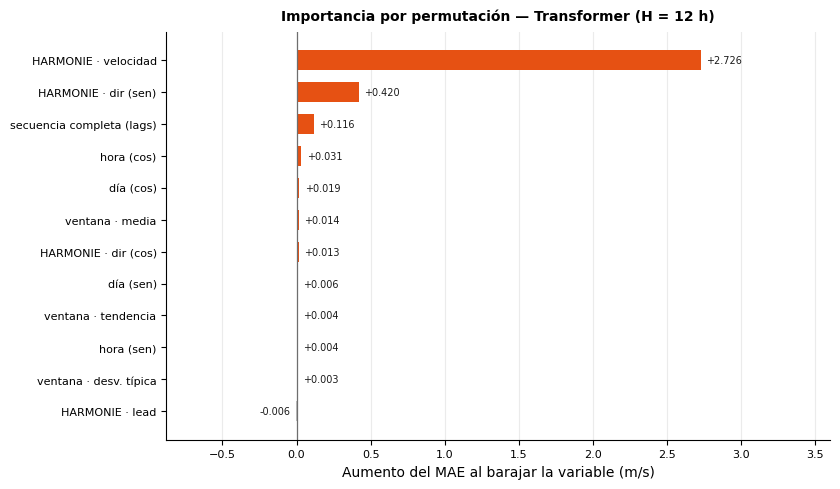

Variables de las que la red depende (aumentan el MAE al barajarse):
  HARMONIE · velocidad         +2.7261 m/s
  HARMONIE · dir (sen)         +0.4202 m/s
  secuencia completa (lags)    +0.1160 m/s
  hora (cos)                   +0.0309 m/s
  día (cos)                    +0.0194 m/s
  ventana · media              +0.0138 m/s
  HARMONIE · dir (cos)         +0.0133 m/s
  día (sen)                    +0.0055 m/s
  ventana · tendencia          +0.0043 m/s
  hora (sen)                   +0.0035 m/s
  ventana · desv. típica       +0.0033 m/s

1 variables con importancia nula o negativa: barajarlas no
empeora la prediccion, de modo que la red no depende de ellas de forma robusta.


In [9]:
(tr_i2, va_i2, te_i2), crudos2, sc2 = datos_para(H_REF, W_OPT)
y_te2 = crudos2[2][2]

torch.manual_seed(SEMILLA)
m_interp = construir_modelo(GANADOR_DL, tr_i2[1].shape[1], PARAMS_FIN)
m_interp, _, _ = entrenar(m_interp, *tr_i2, *va_i2, lr=LR_FINAL, wd=WD_FINAL)

def predecir(Xs_t, Xe_t):
    with torch.no_grad():
        return sc2[2].inverse_transform(
            m_interp(Xs_t, Xe_t).cpu().numpy().reshape(-1, 1)).ravel()

Xs_te_t, Xe_te_t = te_i2[0], te_i2[1]
mae_base = mean_absolute_error(y_te2, predecir(Xs_te_t, Xe_te_t))

rng = np.random.default_rng(SEMILLA)
importancias = {}
for j, nombre in enumerate(ESTATICAS):
    perm = torch.tensor(rng.permutation(Xe_te_t.shape[0]), dtype=torch.long, device=Xe_te_t.device)
    Xe_perm = Xe_te_t.clone()
    Xe_perm[:, j] = Xe_perm[perm, j]
    importancias[nombre] = mean_absolute_error(y_te2, predecir(Xs_te_t, Xe_perm)) - mae_base

perm = torch.tensor(rng.permutation(Xs_te_t.shape[0]), dtype=torch.long, device=Xs_te_t.device)
importancias['secuencia completa (lags)'] = (
    mean_absolute_error(y_te2, predecir(Xs_te_t[perm], Xe_te_t)) - mae_base)

imp = pd.Series(importancias).sort_values()
print(f'MAE base (sin perturbar): {mae_base:.3f}')
display(imp.sort_values(ascending=False).to_frame('aumento_MAE_al_barajar').round(4))

# --- FIGURA: importancia por permutacion --------------------------------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
NEGRO   = '#1A1A1A'

# Nombres legibles, los mismos que emplea la figura SHAP del notebook 4, para
# que ambas puedan compararse variable a variable en la memoria.
LEGIBLE = {
    'H_vel':      'HARMONIE · velocidad',
    'H_dir_sin':  'HARMONIE · dir (sen)',
    'H_dir_cos':  'HARMONIE · dir (cos)',
    'H_lead':     'HARMONIE · lead',
    'lag_media':  'ventana · media',
    'lag_std':    'ventana · desv. típica',
    'lag_tend':   'ventana · tendencia',
    'hora_sin':   'hora (sen)',  'hora_cos': 'hora (cos)',
    'dia_sin':    'día (sen)',   'dia_cos':  'día (cos)',
}
etiquetas = [LEGIBLE.get(v, v) for v in imp.index]

# Una importancia negativa indica que barajar la variable no empeora la
# prediccion: la red no depende de ella de forma robusta. Se distingue en gris
# para que no compita visualmente con las que si aportan.
colores = [NARANJA if v > 0 else '#BFBFBF' for v in imp.values]

fig, ax = plt.subplots(figsize=(8.5, 5))
barras = ax.barh(etiquetas, imp.values, color=colores, height=.62)
ax.axvline(0, color=GRIS, lw=.9)

ax.set_xlabel('Aumento del MAE al barajar la variable (m/s)')
ax.set_title(f'Importancia por permutación — {GANADOR_DL} (H = {H_REF} h)',
             fontsize=10, fontweight='bold', pad=8)
ax.grid(axis='x', alpha=.25)
ax.set_axisbelow(True)
ax.tick_params(labelsize=8)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)

# El valor se anota al extremo de cada barra, del lado que corresponda a su signo.
margen = max(abs(imp.min()), abs(imp.max())) * 0.04
for barra, valor in zip(barras, imp.values):
    ax.annotate(f'{valor:+.3f}',
                xy=(valor, barra.get_y() + barra.get_height()/2),
                xytext=(4 if valor >= 0 else -4, 0), textcoords='offset points',
                va='center', ha='left' if valor >= 0 else 'right',
                fontsize=7, color=NEGRO)
ax.set_xlim(imp.min() - margen*8, imp.max() + margen*8)

plt.tight_layout()

NOMBRE = 'permutacion_dl'
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.show()

# --- Lectura del resultado ----------------------------------------------------
positivas = imp[imp > 0].sort_values(ascending=False)
print('Variables de las que la red depende (aumentan el MAE al barajarse):')
for v, val in positivas.items():
    print(f'  {LEGIBLE.get(v, v):28s} {val:+.4f} m/s')
if (imp <= 0).any():
    print(f'\n{(imp <= 0).sum()} variables con importancia nula o negativa: barajarlas no')
    print('empeora la prediccion, de modo que la red no depende de ellas de forma robusta.')


---
## 7. Guardado

Las predicciones se guardan con la etiqueta de la arquitectura ganadora
(`Transformer (DL)`), que es la que usa el notebook 6.


In [10]:
dl_df = pd.concat([
    pred.rename('pred').to_frame()
        .assign(H=H, modelo=f'{GANADOR_DL} (DL)', real=base[OBJ].reindex(pred.index))
        .reset_index().rename(columns={'index': 'ts'})
    for H, pred in predicciones_finales.items()
], ignore_index=True)
dl_df.to_parquet(RUTA/'dl_predicciones.parquet', index=False)

with open(RUTA/'dl_mejor_modelo.json', 'w') as f:
    json.dump({'ganador': GANADOR_DL, 'ventana': W_OPT, 'afinado': True,
               'hiperparametros': PARAMS_FIN, 'lr': LR_FINAL, 'wd': WD_FINAL,
               'n_semillas_ensemble': N_SEMILLAS_ENSEMBLE,
               'comparacion_arquitecturas': tabla_arq.to_dict('records'),
               'metricas': [{k: v for k, v in r.items() if k != 'MAE_semillas'}
                            for r in resultados_finales]},
              f, indent=2, ensure_ascii=False, default=str)

print(f'Guardado dl_predicciones.parquet ({len(dl_df)} filas) y dl_mejor_modelo.json')

Guardado dl_predicciones.parquet (53593 filas) y dl_mejor_modelo.json


---
## Conclusiones

**Para la memoria:**

* La etapa 1 no deja una ganadora clara (0,007 m/s de separación y criterios que discrepan), lo que justifica afinar las tres.
* La tabla DL / ML / SARIMAX / HARMONIE bruto por horizonte.
* La ganancia del ensemble de semillas: cuantifica la varianza del ajuste, dato relevante
  para el notebook 6.
* Los hiperparámetros ganadores (bidireccionalidad, ventana, profundidad) son material para
  la discusión sobre qué estructura del problema favorece a cada familia.
* La importancia por permutación frente al SHAP del notebook 4: ¿la red encuentra algo que
  los árboles no veían, o confirma la misma estructura?

Si el DL sigue sin superar a XGBoost tras el afinado, es una confirmación robusta —no un
artefacto de una comparación injusta— de que el problema no premia la complejidad del DL
sobre este conjunto de datos. Es un resultado legítimo del objetivo 2.

**Ficheros generados:**

| Fichero | Consumido por |
|---|---|
| `dl_predicciones.parquet` | Notebook 6 (ensemble + Diebold-Mariano) |
| dl_mejor_modelo.json | Notebook 8 (MLflow) |

**Siguiente:** notebook 6 — ensemble entre familias y test de Diebold-Mariano.